In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# ==========================================================
# 1. Reproducibility
# ==========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ==========================================================
# 2. Device
# ==========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using Device: {device}")

# ==========================================================
# 3. Hyperparameters
# ==========================================================

BATCH_SIZE = 64
INPUT_SIZE = 28 * 28
HIDDEN_SIZE = 128
NUM_CLASSES = 10

LEARNING_RATE = 0.001
EPOCHS = 5

# ==========================================================
# 4. Transform
# ==========================================================

transform = transforms.ToTensor()

# ==========================================================
# 5. Dataset
# ==========================================================

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ==========================================================
# 6. Model
# ==========================================================

class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(INPUT_SIZE, HIDDEN_SIZE),

            nn.ReLU(),

            nn.Linear(HIDDEN_SIZE, NUM_CLASSES)

        )

    def forward(self, x):

        return self.network(x)


model = MLP().to(device)

# ==========================================================
# 7. Loss and Optimizer
# ==========================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# ==========================================================
# 8. Accuracy Function
# ==========================================================

def evaluate(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    return 100 * correct / total

# ==========================================================
# 9. Training
# ==========================================================

best_accuracy = 0

print("\nStarting Training...\n")

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_accuracy = evaluate(model, train_loader)

    val_accuracy = evaluate(model, val_loader)

    average_loss = running_loss / len(train_loader)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {average_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.2f}% | "
        f"Validation Accuracy: {val_accuracy:.2f}%"
    )

    if val_accuracy > best_accuracy:

        best_accuracy = val_accuracy

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "validation_accuracy": val_accuracy
            },
            "best_model.pth"
        )

        print("Best model saved.\n")

print("=" * 60)
print(f"Best Validation Accuracy: {best_accuracy:.2f}%")
print("=" * 60)

# ==========================================================
# 10. Load Best Model
# ==========================================================

checkpoint = torch.load(
    "best_model.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

print("\nBest model loaded successfully!")

# ==========================================================
# 11. Inference Function
# ==========================================================

def predict(model, image):

    model.eval()

    with torch.no_grad():

        image = image.unsqueeze(0).to(device)

        output = model(image)

        prediction = output.argmax(dim=1)

    return prediction.item()

# ==========================================================
# 12. Demo Prediction
# ==========================================================

image, label = val_dataset[0]

prediction = predict(model, image)

print("\nInference Demo")
print("----------------")
print(f"Actual Label     : {label}")
print(f"Predicted Label  : {prediction}")

Using Device: cuda

Starting Training...

Epoch [1/5] | Loss: 0.3727 | Train Accuracy: 94.15% | Validation Accuracy: 93.22%
Best model saved.

Epoch [2/5] | Loss: 0.1746 | Train Accuracy: 96.37% | Validation Accuracy: 95.09%
Best model saved.

Epoch [3/5] | Loss: 0.1220 | Train Accuracy: 97.26% | Validation Accuracy: 96.03%
Best model saved.

Epoch [4/5] | Loss: 0.0922 | Train Accuracy: 98.12% | Validation Accuracy: 96.62%
Best model saved.

Epoch [5/5] | Loss: 0.0727 | Train Accuracy: 98.33% | Validation Accuracy: 96.92%
Best model saved.

Best Validation Accuracy: 96.92%

Best model loaded successfully!

Inference Demo
----------------
Actual Label     : 2
Predicted Label  : 2


In [3]:
train_loss_history = []
train_acc_history = []
val_acc_history = []

train_loss_history.append(average_loss)
train_acc_history.append(train_accuracy)
val_acc_history.append(val_accuracy)

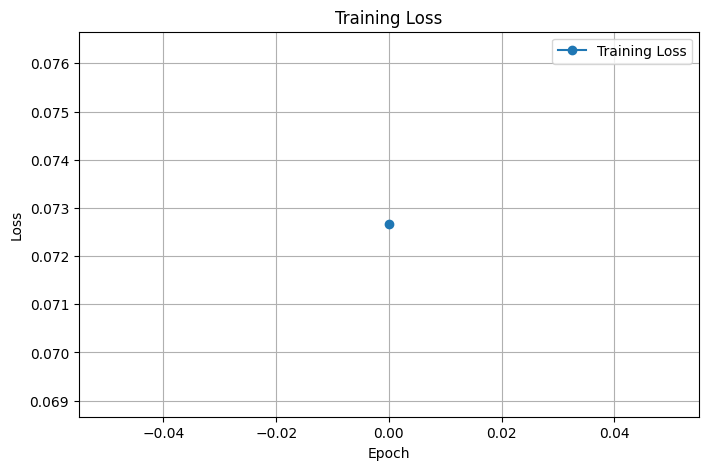

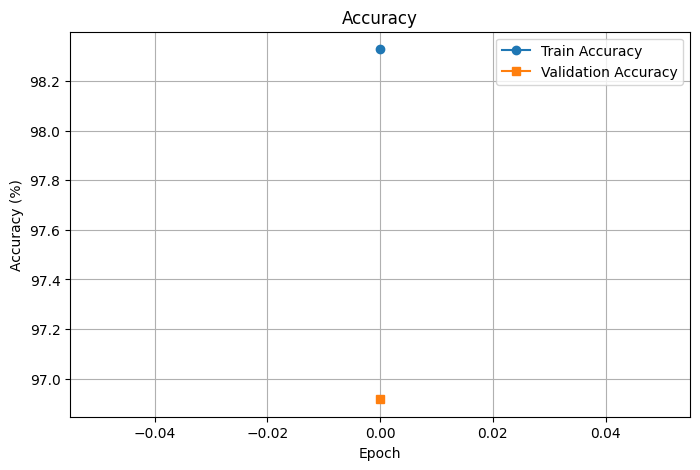

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_loss_history, marker="o", label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(train_acc_history, marker="o", label="Train Accuracy")
plt.plot(val_acc_history, marker="s", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [6]:
true_labels = []
pred_labels = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        true_labels.extend(labels.numpy())
        pred_labels.extend(predicted.cpu().numpy())

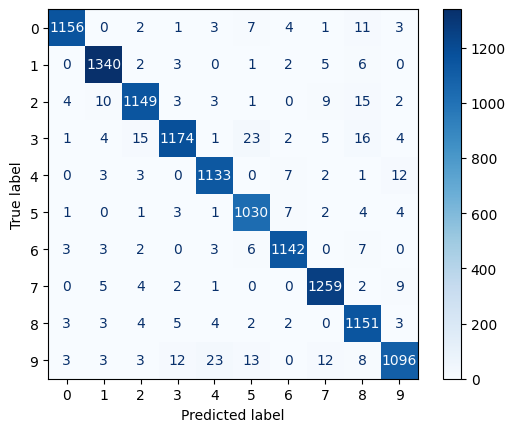

In [7]:
cm = confusion_matrix(true_labels, pred_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.show()

In [8]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        pred_labels
    )
)

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1188
           1       0.98      0.99      0.98      1359
           2       0.97      0.96      0.97      1196
           3       0.98      0.94      0.96      1245
           4       0.97      0.98      0.97      1161
           5       0.95      0.98      0.96      1053
           6       0.98      0.98      0.98      1166
           7       0.97      0.98      0.98      1282
           8       0.94      0.98      0.96      1177
           9       0.97      0.93      0.95      1173

    accuracy                           0.97     12000
   macro avg       0.97      0.97      0.97     12000
weighted avg       0.97      0.97      0.97     12000



In [9]:
plt.savefig("training_loss.png")
plt.savefig("accuracy.png")

<Figure size 640x480 with 0 Axes>